In [43]:
#  Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [44]:
from google.colab import files
upload = files.upload()

Saving Products_.csv to Products_ (1).csv


In [45]:
df = pd.read_csv('Products_.csv')

print("Shape:", df.shape)
df.head()

Shape: (2517, 16)


,Product_id,product_name,Brand,Color,Unit_Cost_USD,Unit_Price_USD,Subcategory_id,Sub_category,Category_id,Category,unit_profit,profit_margin_%,cost_category,price_category,name_length,brand_category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio,6.37,49%,Low Cost,Budget,35,Contoso - Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio,6.37,49%,Low Cost,Budget,33,Contoso - Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio,7.12,49%,Low Cost,Budget,32,Contoso - Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio,10.57,49%,Low Cost,Budget,33,Contoso - Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio,10.57,49%,Low Cost,Budget,30,Contoso - Audio


In [46]:
df.info()
print("\nColumn names:", list(df.columns))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product_id       2517 non-null   int64  
 1   product_name     2517 non-null   object 
 2   Brand            2517 non-null   object 
 3   Color            2517 non-null   object 
 4   Unit_Cost_USD    2517 non-null   float64
 5   Unit_Price_USD   2517 non-null   float64
 6   Subcategory_id   2517 non-null   int64  
 7   Sub_category     2517 non-null   object 
 8   Category_id      2517 non-null   int64  
 9   Category         2517 non-null   object 
 10  unit_profit      2517 non-null   float64
 11  profit_margin_%  2517 non-null   object 
 12  cost_category    2517 non-null   object 
 13  price_category   2517 non-null   object 
 14  name_length      2517 non-null   int64  
 15  brand_category   2517 non-null   object 
dtypes: float64(3), int64(4), object(9)
memory usage: 314.8+ KB



In [47]:
#  Check for nulls and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nFully duplicate rows:", df.duplicated().sum())
print("Duplicate Product_id:", df['Product_id'].duplicated().sum())

Missing values per column:
 Product_id         0
product_name       0
Brand              0
Color              0
Unit_Cost_USD      0
Unit_Price_USD     0
Subcategory_id     0
Sub_category       0
Category_id        0
Category           0
unit_profit        0
profit_margin_%    0
cost_category      0
price_category     0
name_length        0
brand_category     0
dtype: int64

Fully duplicate rows: 0
Duplicate Product_id: 0


In [48]:
# Clean column name
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['product_id', 'product_name', 'brand', 'color', 'unit_cost_usd', 'unit_price_usd', 'subcategory_id', 'sub_category', 'category_id', 'category', 'unit_profit', 'profit_margin_%', 'cost_category', 'price_category', 'name_length', 'brand_category']


In [49]:
# Strip whitespace from all text/object columns as excel often leaves trailing/leading spaces after copy-paste
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

print("Cleaned text columns:", list(text_cols))

Cleaned text columns: ['product_name', 'brand', 'color', 'sub_category', 'category', 'profit_margin_%', 'cost_category', 'price_category', 'brand_category']


In [50]:
# Standardizing categorical text casing Ensures 'audio' and 'Audio' aren't treated as different categories

df['category'] = df['category'].str.replace(r'\bAnd\b', 'and', regex=True)
df['category'] = df['category'].str.replace('Tv', 'TV')
df['sub_category'] = df['sub_category'].str.replace(r'\bAnd\b', 'and', regex=True)
df['brand'] = df['brand'].str.title()
df['color'] = df['color'].str.title()

print(df['category'].unique())

['Audio' 'TV and Video' 'Computers' 'Cameras and camcorders' 'Cell phones'
 'Music, Movies and Audio Books' 'Games and Toys' 'Home Appliances']


In [51]:
# Fixing profit_margin_% column,It's stored as text like "49%" -> convert to numeric float (49.0)
df['profit_margin_%'] = (
    df['profit_margin_%']
    .astype(str)
    .str.replace('%', '', regex=False)
    .astype(float)
)

df['profit_margin_%'].head()

,profit_margin_%
0,49.0
1,49.0
2,49.0
3,49.0
4,49.0


In [52]:
# Recalculating derived columns in Python instead of trusting Excel's formulas - this validates the cleaned data

# unit profit = price - cost
df['unit_profit_calc'] = (df['unit_price_usd'] - df['unit_cost_usd']).round(2)

# profit margin % = (profit / price) * 100
df['profit_margin_calc'] = ((df['unit_profit_calc'] / df['unit_price_usd']) * 100).round(2)

# Compare Excel's values vs recalculated values
df['profit_mismatch'] = (df['unit_profit'] - df['unit_profit_calc']).abs() > 0.01
print("Rows where Excel unit_profit differs from recalculated value:", df['profit_mismatch'].sum())

df[df['profit_mismatch']][['product_name', 'unit_cost_usd', 'unit_price_usd', 'unit_profit', 'unit_profit_calc']]

Rows where Excel unit_profit differs from recalculated value: 0


,product_name,unit_cost_usd,unit_price_usd,unit_profit,unit_profit_calc


In [53]:
# Dropping the mismatch flag and old Excel-calculated columns
df.drop(columns=['unit_profit', 'profit_margin_%', 'profit_mismatch'], inplace=True)
df.rename(columns={'unit_profit_calc': 'unit_profit',
                    'profit_margin_calc': 'profit_margin_%'}, inplace=True)

df.head()

,product_id,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategory_id,sub_category,category_id,category,cost_category,price_category,name_length,brand_category,unit_profit,profit_margin_%
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio,Low Cost,Budget,35,Contoso - Audio,6.37,49.04
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio,Low Cost,Budget,33,Contoso - Audio,6.37,49.04
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio,Low Cost,Budget,32,Contoso - Audio,7.12,49.04
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio,Low Cost,Budget,33,Contoso - Audio,10.57,49.00
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio,Low Cost,Budget,30,Contoso - Audio,10.57,49.00


In [54]:
# Rebuilding cost_category and price_category clear, reproducible rules
def cost_bucket(cost):
    if cost < 50:
        return 'Low Cost'
    elif cost < 200:
        return 'Medium Cost'
    else:
        return 'High Cost'

def price_bucket(price):
    if price < 100:
        return 'Budget'
    elif price < 500:
        return 'Mid Range'
    else:
        return 'Premium'

df['cost_category'] = df['unit_cost_usd'].apply(cost_bucket)
df['price_category'] = df['unit_price_usd'].apply(price_bucket)

df[['unit_cost_usd', 'cost_category', 'unit_price_usd', 'price_category']].head()

,unit_cost_usd,cost_category,unit_price_usd,price_category
0,6.62,Low Cost,12.99,Budget
1,6.62,Low Cost,12.99,Budget
2,7.40,Low Cost,14.52,Budget
3,11.00,Low Cost,21.57,Budget
4,11.00,Low Cost,21.57,Budget


In [55]:
# Checking for logical errors
# (e.g. price should never be less than cost -> negative profit)
invalid_products = df[df['unit_profit'] < 0]
print("Products where price < cost:", len(invalid_products))
invalid_products[['product_name', 'unit_cost_usd', 'unit_price_usd', 'unit_profit']]

Products where price < cost: 0


,product_name,unit_cost_usd,unit_price_usd,unit_profit


In [56]:
# Checking for outliers using IQR method on price
Q1 = df['unit_price_usd'].quantile(0.25)
Q3 = df['unit_price_usd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['unit_price_usd'] < lower) | (df['unit_price_usd'] > upper)]
print(f"Price outliers (outside {lower:.2f} - {upper:.2f}): {len(outliers)} products")

Price outliers (outside -442.50 - 921.50): 200 products


In [57]:
# Final data quality summary
print("Final shape:", df.shape)
print("\nNull values:\n", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
df.describe()

Final shape: (2517, 16)

Null values:
 0

Duplicate rows: 0

Data types:
 product_id           int64
product_name        object
brand               object
color               object
unit_cost_usd      float64
unit_price_usd     float64
subcategory_id       int64
sub_category        object
category_id          int64
category            object
cost_category       object
price_category      object
name_length          int64
brand_category      object
unit_profit        float64
profit_margin_%    float64
dtype: object


,product_id,unit_cost_usd,unit_price_usd,subcategory_id,category_id,name_length,unit_profit,profit_margin_%
count,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000,2517.000000
mean,1259.000000,147.655562,356.830131,491.810091,4.878824,40.675010,209.174569,54.585085
std,726.739637,184.373683,494.054962,229.887134,2.299170,10.173693,316.356201,6.421078
min,1.000000,0.480000,0.950000,101.000000,1.000000,19.000000,0.470000,48.950000
25%,630.000000,32.250000,69.000000,305.000000,3.000000,33.000000,36.730000,49.020000
50%,1259.000000,86.670000,199.990000,406.000000,4.000000,40.000000,108.000000,54.010000
75%,1888.000000,183.950000,410.000000,801.000000,8.000000,48.000000,231.720000,54.020000
max,2517.000000,1060.220000,3199.990000,808.000000,8.000000,83.000000,2139.770000,66.890000


In [58]:
# Save the cleaned file
df.to_csv('Products_py.csv', index=False)
files.download('Products_py.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **INSIGHTS**

In [59]:
# 1: How many products, categories, brands
print("Total products:", df.shape[0])
print("Total categories:", df['category'].nunique())
print("Total brands:", df['brand'].nunique())

Total products: 2517
Total categories: 8
Total brands: 11


In [60]:
# 2: Average price, cost, and profit
print("Average price:", df['unit_price_usd'].mean())
print("Average cost:", df['unit_cost_usd'].mean())
print("Average profit:", df['unit_profit'].mean())

Average price: 356.8301311084624
Average cost: 147.65556217719507
Average profit: 209.17456893126737


In [61]:
# 3: Highest and lowest priced product
print("Most expensive product:")
print(df[df['unit_price_usd'] == df['unit_price_usd'].max()][['product_name', 'unit_price_usd']])

print("\nCheapest product:")
print(df[df['unit_price_usd'] == df['unit_price_usd'].min()][['product_name', 'unit_price_usd']])

Most expensive product:
                                     product_name  unit_price_usd
1896   Fabrikam Refrigerator 24.7CuFt X9800 White         3199.99
1902   Fabrikam Refrigerator 24.7CuFt X9800 Brown         3199.99
1908  Fabrikam Refrigerator 24.7CuFt X9800 Silver         3199.99
1914   Fabrikam Refrigerator 24.7CuFt X9800 Green         3199.99
1920    Fabrikam Refrigerator 24.7CuFt X9800 Blue         3199.99
1926    Fabrikam Refrigerator 24.7CuFt X9800 Grey         3199.99
1932  Fabrikam Refrigerator 24.7CuFt X9800 Orange         3199.99
1938     Litware Refrigerator 24.7CuFt X980 White         3199.99
1944     Litware Refrigerator 24.7CuFt X980 Brown         3199.99
1950    Litware Refrigerator 24.7CuFt X980 Silver         3199.99
1956     Litware Refrigerator 24.7CuFt X980 Green         3199.99
1962      Litware Refrigerator 24.7CuFt X980 Blue         3199.99
1968      Litware Refrigerator 24.7CuFt X980 Grey         3199.99
1974            Litware Refrigerator L1200 Orange   

In [62]:
# 4: How many products in each category
df['category'].value_counts()

,count
category,
Home Appliances,661
Computers,606
Cameras and camcorders,372
Cell phones,285
TV and Video,222
Games and Toys,166
Audio,115
"Music, Movies and Audio Books",90


In [63]:
# 5: How many products for each brand
df['brand'].value_counts()

,count
brand,
Contoso,710
Fabrikam,267
Litware,264
Proseware,244
Southridge Video,192
Adventure Works,192
Wide World Importers,173
The Phone Company,152
Tailspin Toys,144


In [64]:
# 6: Which category has the highest average price
df.groupby('category')['unit_price_usd'].mean().sort_values(ascending=False)

,unit_price_usd
category,
Home Appliances,537.802738
TV and Video,497.588378
Cameras and camcorders,400.321774
Computers,331.702310
Cell phones,174.871404
Audio,135.879043
"Music, Movies and Audio Books",108.146000
Games and Toys,42.532108


In [65]:
# 7: Which category has the highest average profit margin
df.groupby('category')['profit_margin_%'].mean().sort_values(ascending=False)

,profit_margin_%
category,
"Music, Movies and Audio Books",57.240444
Cameras and camcorders,56.848253
Audio,55.281913
Cell phones,54.913825
Computers,54.767046
TV and Video,53.885721
Home Appliances,53.363843
Games and Toys,52.160542


In [66]:
# 8: Top 5 most expensive products
df.sort_values('unit_price_usd', ascending=False).head(5)[['product_name', 'brand', 'unit_price_usd']]

,product_name,brand,unit_price_usd
1920,Fabrikam Refrigerator 24.7CuFt X9800 Blue,Fabrikam,3199.99
1914,Fabrikam Refrigerator 24.7CuFt X9800 Green,Fabrikam,3199.99
1902,Fabrikam Refrigerator 24.7CuFt X9800 Brown,Fabrikam,3199.99
1908,Fabrikam Refrigerator 24.7CuFt X9800 Silver,Fabrikam,3199.99
1896,Fabrikam Refrigerator 24.7CuFt X9800 White,Fabrikam,3199.99


In [67]:
# 9: Top 5 highest profit margin products
df.sort_values('profit_margin_%', ascending=False).head(5)[['product_name', 'unit_cost_usd', 'unit_price_usd', 'profit_margin_%']]

,product_name,unit_cost_usd,unit_price_usd,profit_margin_%
1584,SV DVD 60 DVD Storage Binder L20 Black,7.58,22.89,66.89
1589,SV DVD 60 DVD Storage Binder L20 Silver,7.58,22.89,66.89
1594,SV DVD 60 DVD Storage Binder L20 Red,7.58,22.89,66.89
1634,Contoso DVD 60 DVD Storage Binder L20 Silver,7.58,22.89,66.89
1639,Contoso DVD 60 DVD Storage Binder L20 Red,7.58,22.89,66.89


In [68]:
# 10: Summary
print("INSIGHTS SUMMARY")
print("Total products:", df.shape[0])
print("Most common category:", df['category'].value_counts().idxmax())
print("Category with highest avg price:", df.groupby('category')['unit_price_usd'].mean().idxmax())
print("Category with highest avg margin:", df.groupby('category')['profit_margin_%'].mean().idxmax())

INSIGHTS SUMMARY
Total products: 2517
Most common category: Home Appliances
Category with highest avg price: Home Appliances
Category with highest avg margin: Music, Movies and Audio Books


# **VISUALIZATIONS**

/tmp/ipykernel_960/1476613266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='viridis')


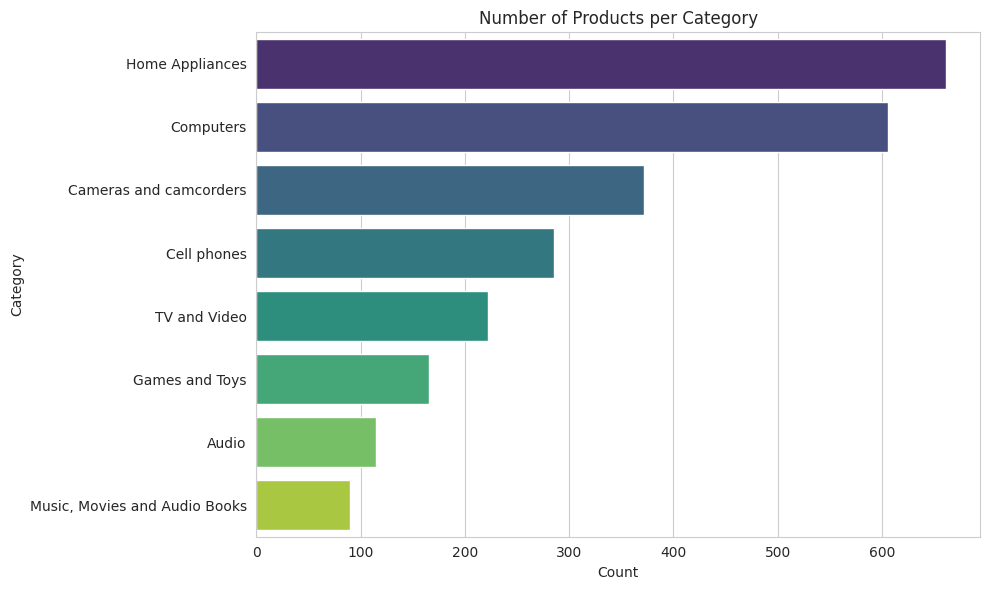

In [69]:
# Products count per category
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='viridis')
plt.title('Number of Products per Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

/tmp/ipykernel_960/979583679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sub.values, y=top_sub.index, palette='mako')


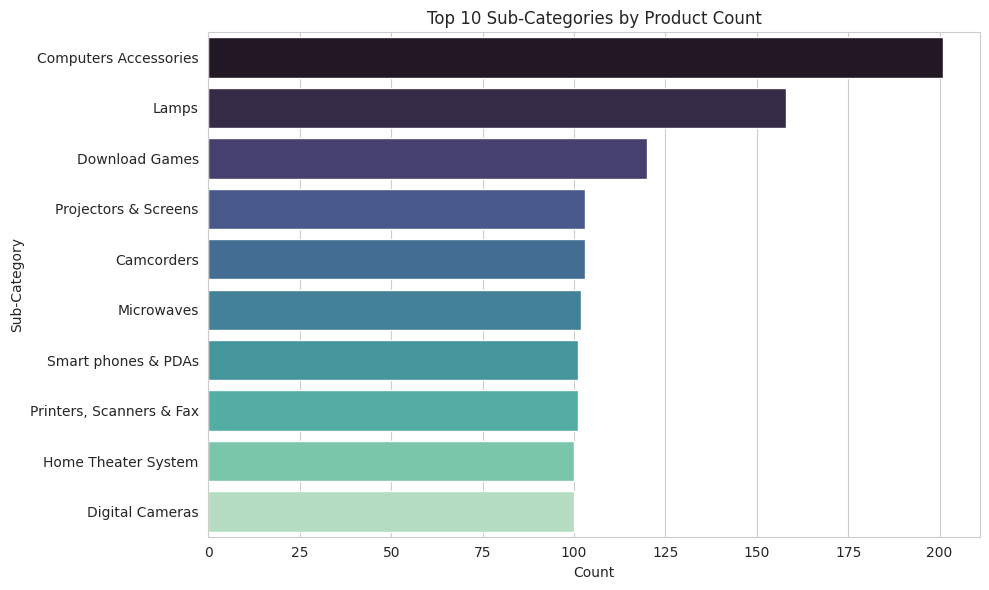

In [70]:
# Top 10 sub-categories by product count
plt.figure(figsize=(10,6))
top_sub = df['sub_category'].value_counts().head(10)
sns.barplot(x=top_sub.values, y=top_sub.index, palette='mako')
plt.title('Top 10 Sub-Categories by Product Count')
plt.xlabel('Count')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

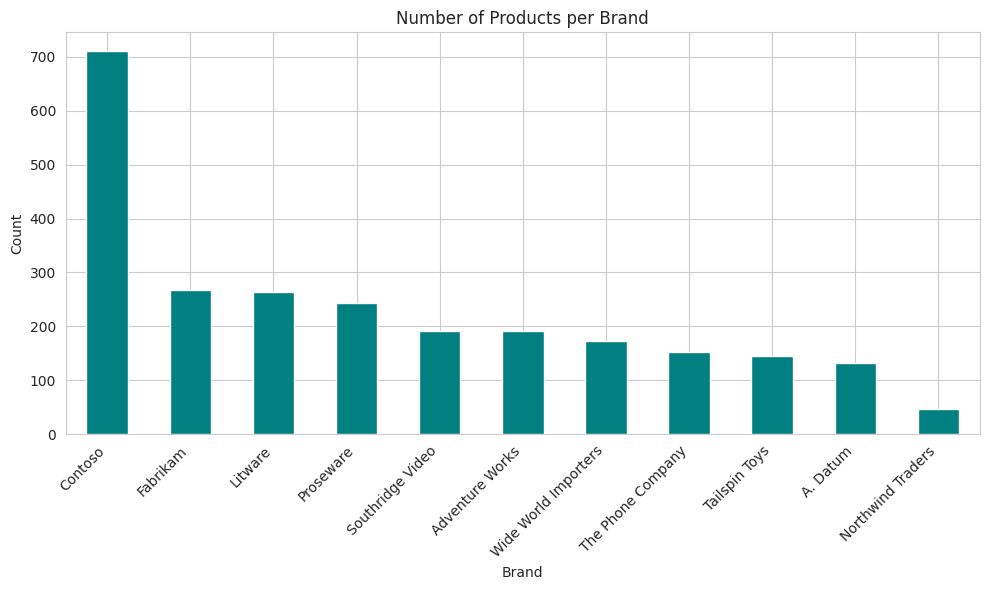

In [71]:
# Brand distribution
plt.figure(figsize=(10,6))
df['brand'].value_counts().plot(kind='bar', color='teal')
plt.title('Number of Products per Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

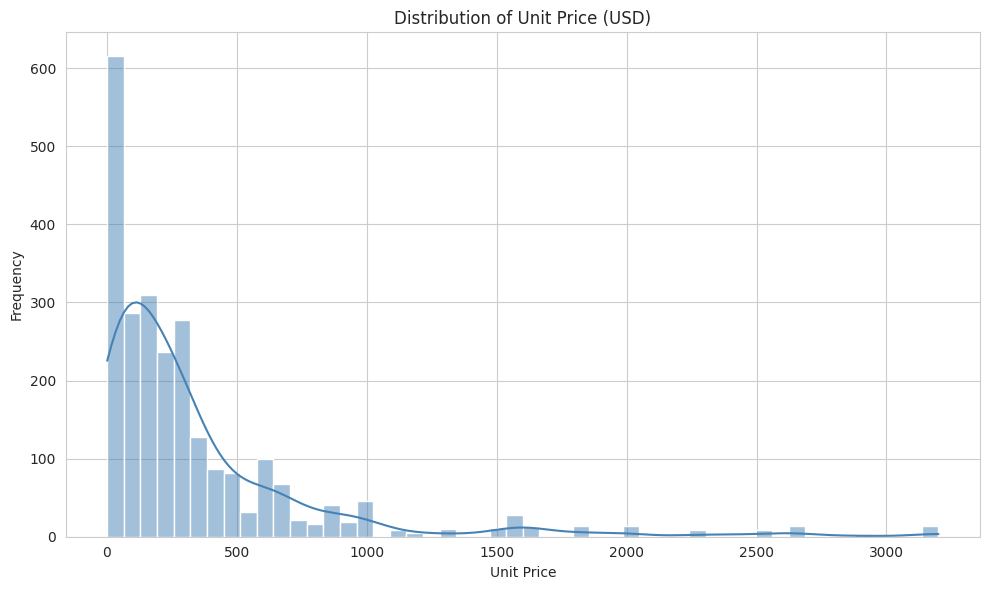

In [72]:
# Price distribution (histogram)
plt.figure(figsize=(10,6))
sns.histplot(df['unit_price_usd'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Unit Price (USD)')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

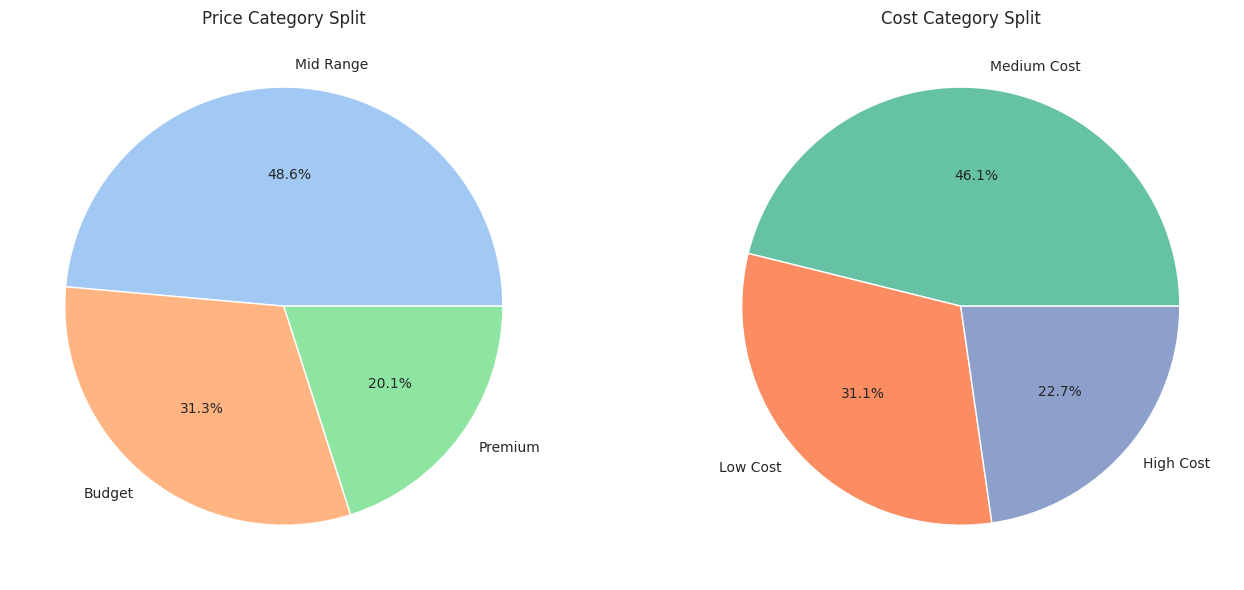

In [73]:
# Price category & cost category breakdown
fig, axes = plt.subplots(1, 2, figsize=(14,6))

df['price_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=sns.color_palette('pastel'))
axes[0].set_title('Price Category Split')
axes[0].set_ylabel('')

df['cost_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('Set2'))
axes[1].set_title('Cost Category Split')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

/tmp/ipykernel_960/2626803540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_margin.values, y=avg_margin.index, palette='coolwarm')


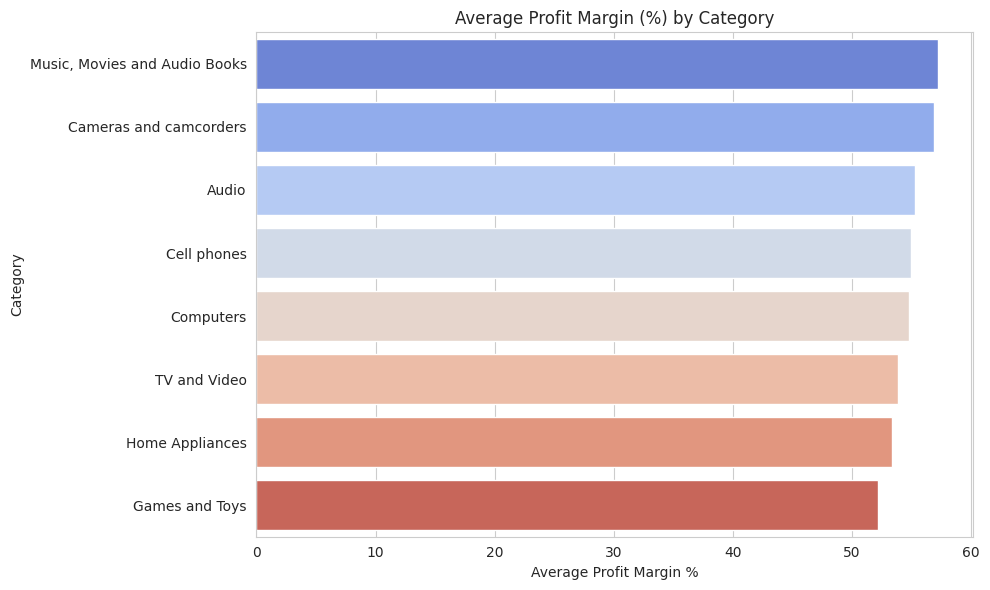

In [74]:
# Average profit margin by category
plt.figure(figsize=(10,6))
avg_margin = df.groupby('category')['profit_margin_%'].mean().sort_values(ascending=False)
sns.barplot(x=avg_margin.values, y=avg_margin.index, palette='coolwarm')
plt.title('Average Profit Margin (%) by Category')
plt.xlabel('Average Profit Margin %')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

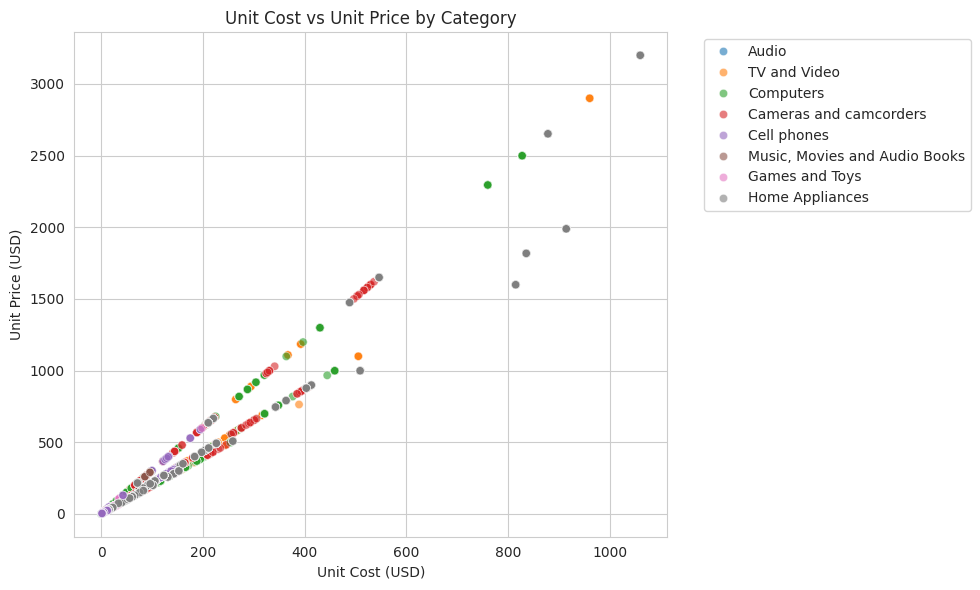

In [75]:
# Unit cost vs Unit price (scatter) - shows pricing strategy
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='unit_cost_usd', y='unit_price_usd', hue='category', alpha=0.6)
plt.title('Unit Cost vs Unit Price by Category')
plt.xlabel('Unit Cost (USD)')
plt.ylabel('Unit Price (USD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_960/3050185554.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='unit_price_usd', palette='Set3')


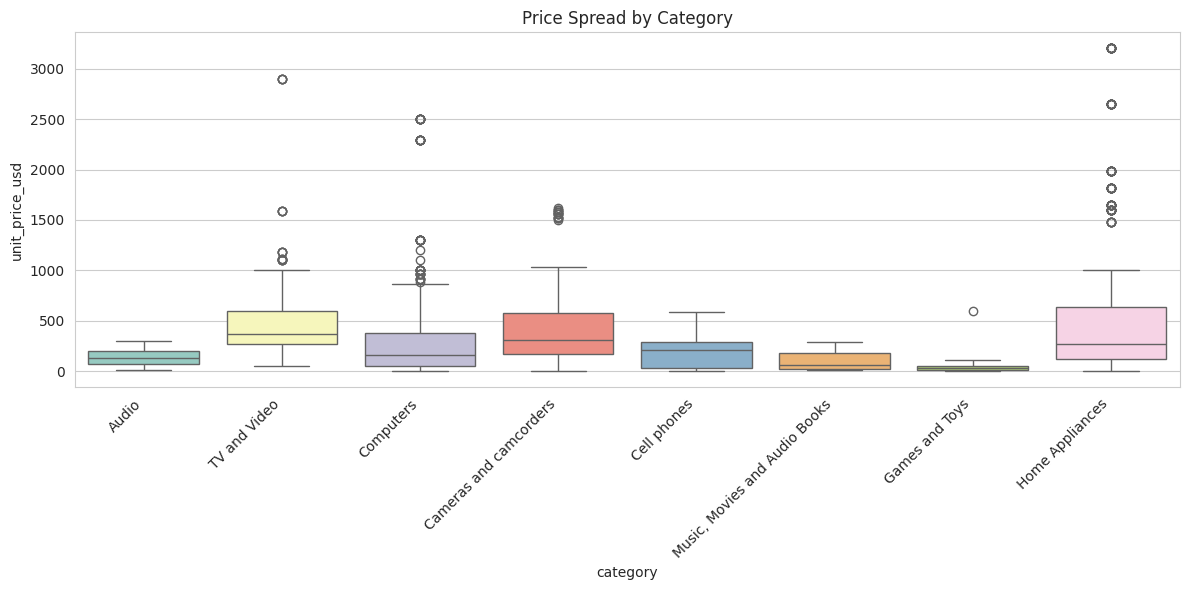

In [76]:
# Boxplot - Price spread across categories (detect outliers visually)
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='category', y='unit_price_usd', palette='Set3')
plt.title('Price Spread by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

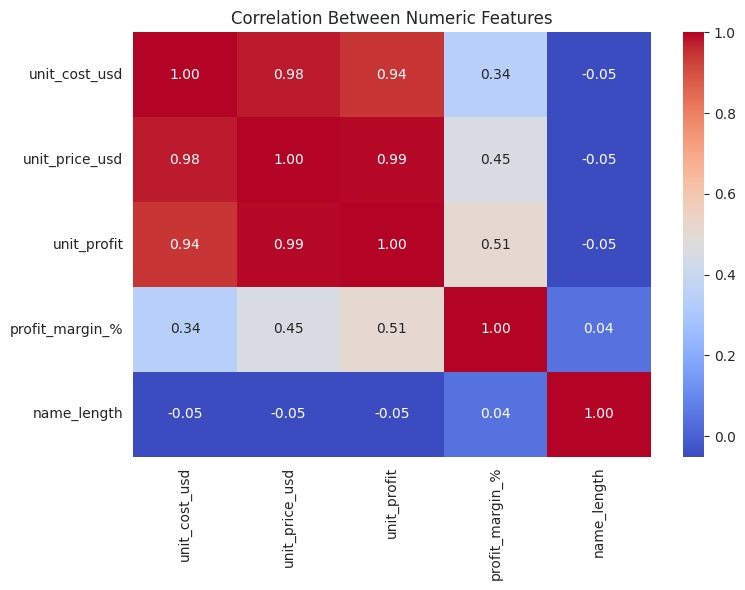

In [77]:
# Correlation heatmap of numeric columns
plt.figure(figsize=(8,6))
numeric_cols = ['unit_cost_usd', 'unit_price_usd', 'unit_profit', 'profit_margin_%', 'name_length']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.show()